In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose

plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (14, 6)


In [2]:
train = pd.read_csv("../data/raw/train.csv")
features = pd.read_csv("../data/raw/features.csv")
stores = pd.read_csv("../data/raw/stores.csv")


In [3]:
print("TRAIN")
display(train.head())
print(train.info())

print("\nFEATURES")
display(features.head())
print(features.info())

print("\nSTORES")
display(stores.head())
print(stores.info())


TRAIN


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB
None

FEATURES


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), object(1)
memory usage: 712.0+ KB
None

STORES


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   45 non-null     int64 
 1   Type    45 non-null     object
 2   Size    45 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ KB
None


In [4]:
df = train.merge(
    features,
    on=["Store", "Date", "IsHoliday"],
    how="left"
)

df = df.merge(
    stores,
    on="Store",
    how="left"
)

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

display(df.head())


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
277665,29,5,2010-02-05,15552.08,False,24.36,2.788,NaN,NaN,NaN,NaN,NaN,131.527903,10.064,B,93638
277808,29,6,2010-02-05,3200.22,False,24.36,2.788,NaN,NaN,NaN,NaN,NaN,131.527903,10.064,B,93638
277951,29,7,2010-02-05,10820.05,False,24.36,2.788,NaN,NaN,NaN,NaN,NaN,131.527903,10.064,B,93638
278094,29,8,2010-02-05,20055.64,False,24.36,2.788,NaN,NaN,NaN,NaN,NaN,131.527903,10.064,B,93638


In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing


MarkDown2    310322
MarkDown4    286603
MarkDown3    284479
MarkDown1    270889
MarkDown5    270138
dtype: int64

In [6]:
df["Temperature"].fillna(df["Temperature"].median(), inplace=True)
df["Fuel_Price"].fillna(df["Fuel_Price"].median(), inplace=True)
df["CPI"].fillna(df["CPI"].median(), inplace=True)
df["Unemployment"].fillna(df["Unemployment"].median(), inplace=True)


C:\Users\prana\AppData\Local\Temp\ipykernel_12048\460673368.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Temperature"].fillna(df["Temperature"].median(), inplace=True)
C:\Users\prana\AppData\Local\Temp\ipykernel_12048\460673368.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as 

In [7]:
df["Weekly_Sales"].describe()


count    421570.000000
mean      15981.258123
std       22711.183519
min       -4988.940000
25%        2079.650000
50%        7612.030000
75%       20205.852500
max      693099.360000
Name: Weekly_Sales, dtype: float64

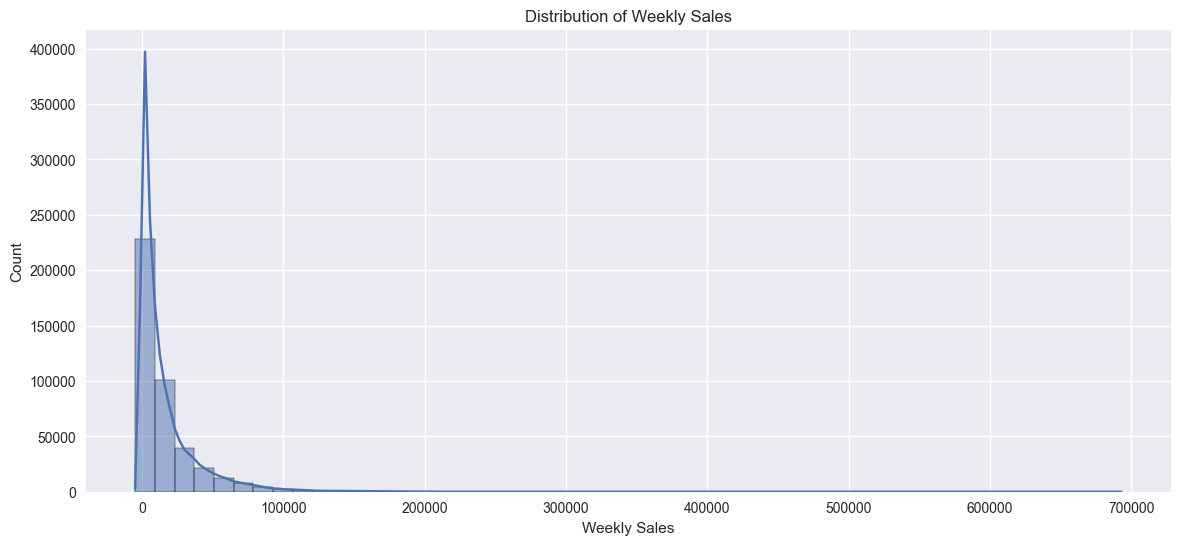

In [8]:
sns.histplot(df["Weekly_Sales"], bins=50, kde=True)
plt.title("Distribution of Weekly Sales")
plt.xlabel("Weekly Sales")
plt.show()


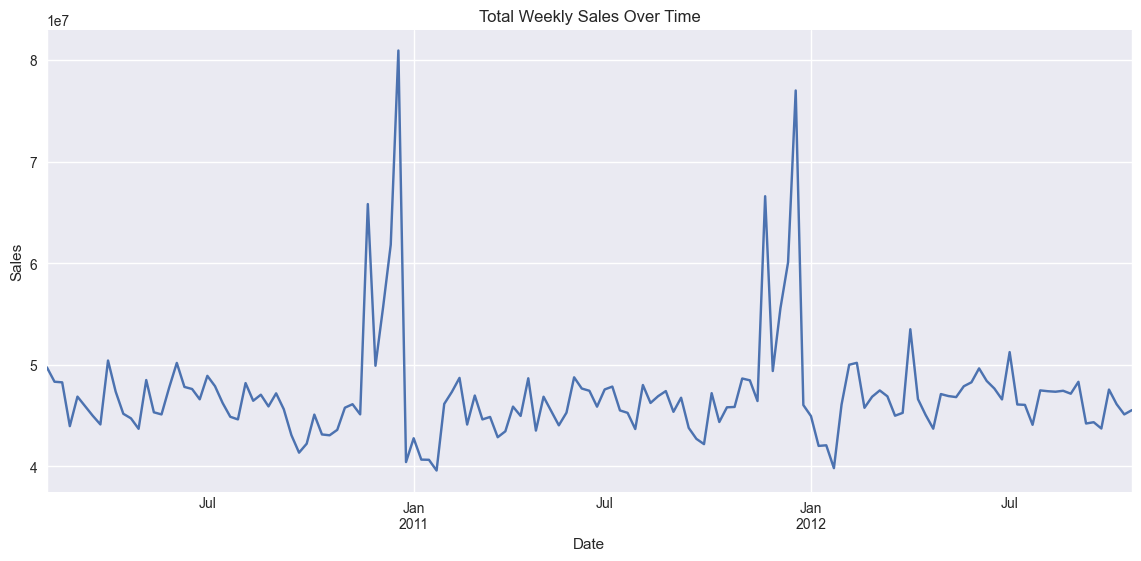

In [9]:
total_sales = df.groupby("Date")["Weekly_Sales"].sum()

total_sales.plot()
plt.title("Total Weekly Sales Over Time")
plt.ylabel("Sales")
plt.xlabel("Date")
plt.show()


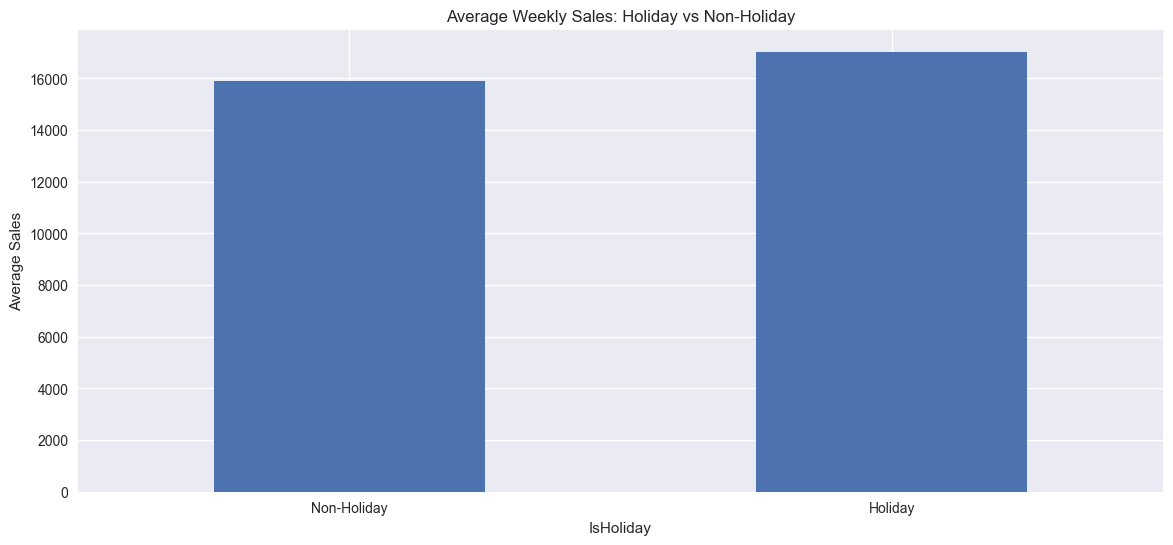

In [10]:
holiday_sales = df.groupby("IsHoliday")["Weekly_Sales"].mean()

holiday_sales.plot(kind="bar")
plt.title("Average Weekly Sales: Holiday vs Non-Holiday")
plt.xticks([0, 1], ["Non-Holiday", "Holiday"], rotation=0)
plt.ylabel("Average Sales")
plt.show()


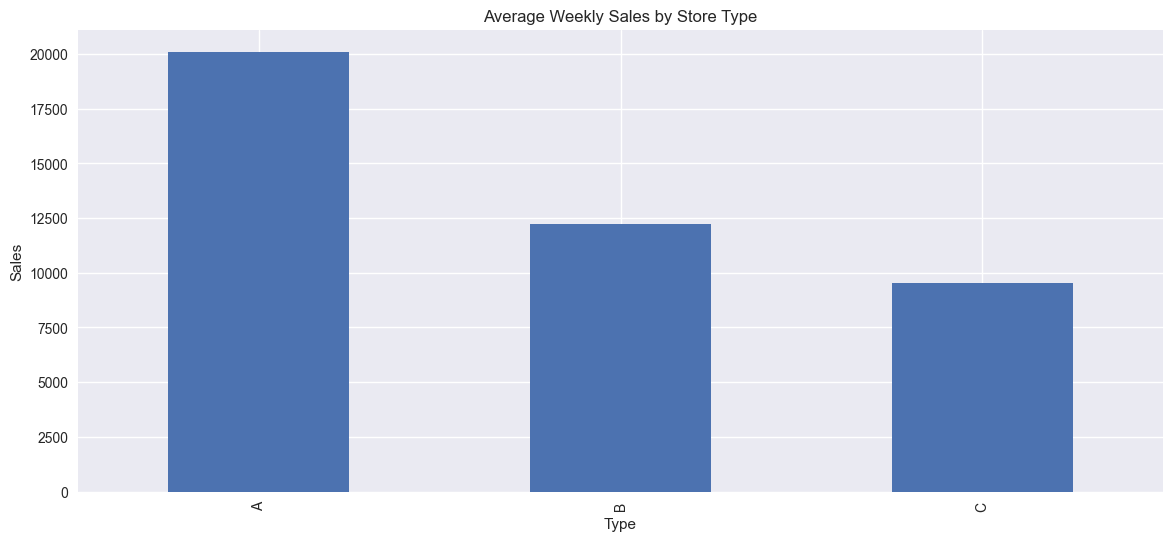

In [11]:
store_type_sales = df.groupby("Type")["Weekly_Sales"].mean()

store_type_sales.plot(kind="bar")
plt.title("Average Weekly Sales by Store Type")
plt.ylabel("Sales")
plt.show()


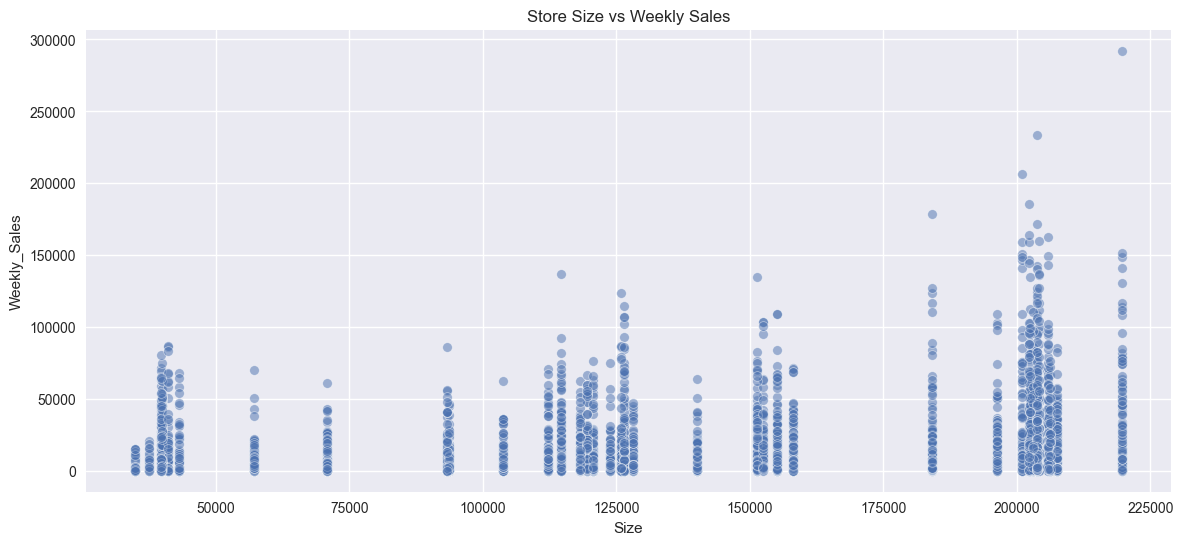

In [12]:
sns.scatterplot(
    data=df.sample(5000, random_state=42),
    x="Size",
    y="Weekly_Sales",
    alpha=0.5
)

plt.title("Store Size vs Weekly Sales")
plt.show()


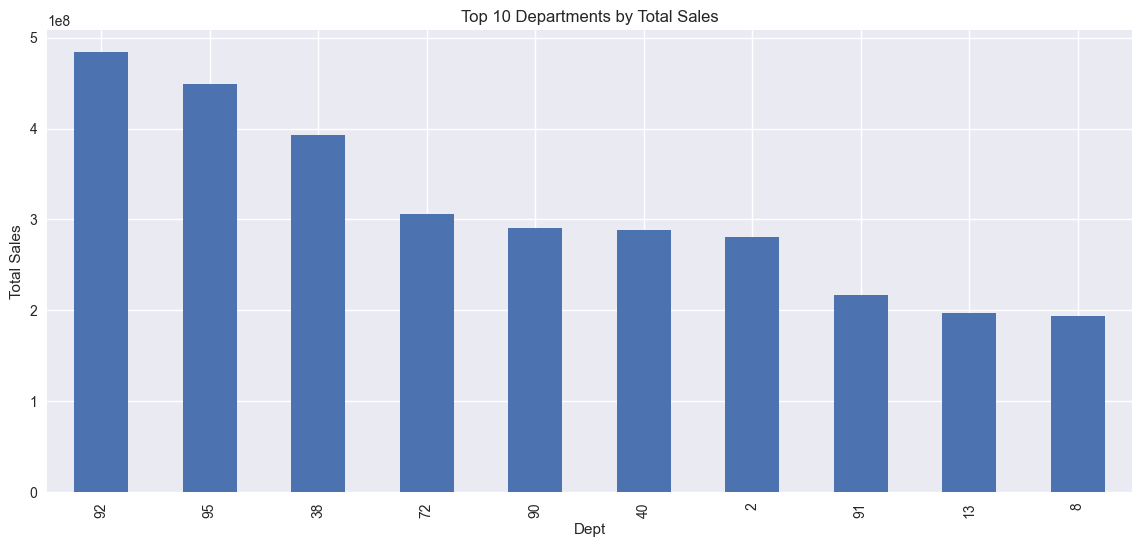

In [13]:
top_departments = (
    df.groupby("Dept")["Weekly_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_departments.plot(kind="bar")
plt.title("Top 10 Departments by Total Sales")
plt.ylabel("Total Sales")
plt.show()


In [14]:
store_dept_sales = (
    df[(df["Store"] == 1) & (df["Dept"] == 1)]
    .groupby("Date")["Weekly_Sales"]
    .sum()
)


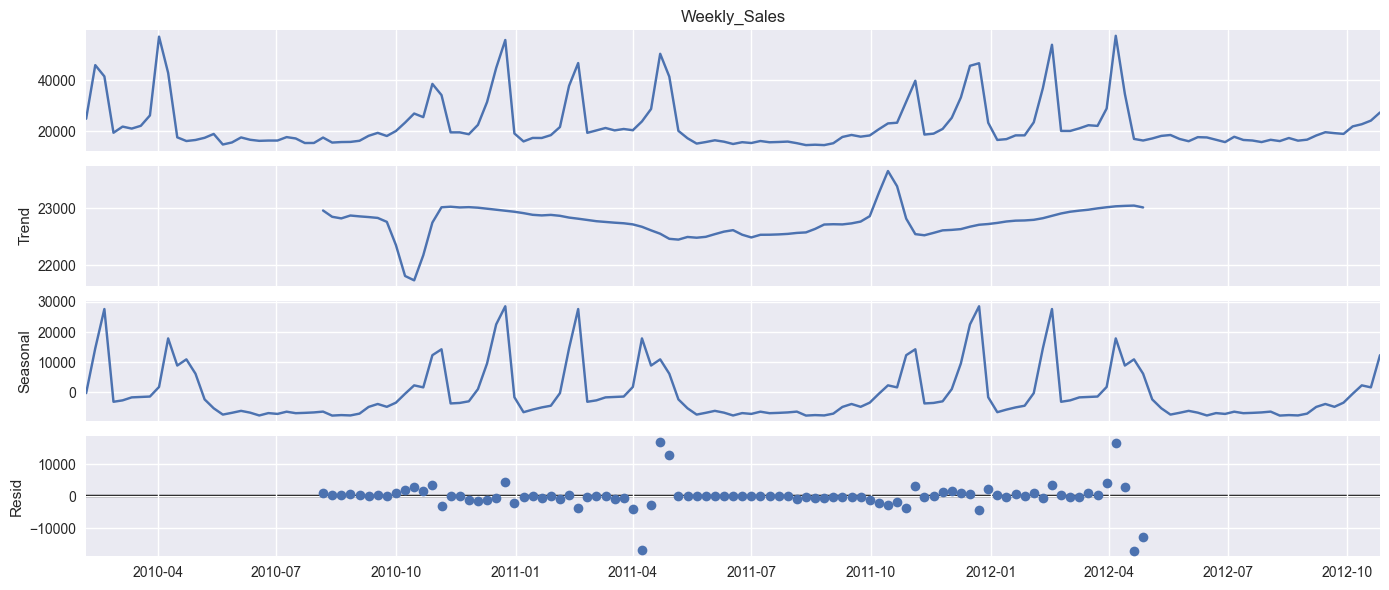

In [15]:
decomposition = seasonal_decompose(
    store_dept_sales,
    model="additive",
    period=52
)

decomposition.plot()
plt.show()


In [16]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)
df["DayOfWeek"] = df["Date"].dt.dayofweek


In [17]:
df["Sales_Lag_1"] = df.groupby(["Store", "Dept"])["Weekly_Sales"].shift(1)
df["Sales_Lag_4"] = df.groupby(["Store", "Dept"])["Weekly_Sales"].shift(4)


In [18]:
df["Rolling_Mean_4"] = (
    df.groupby(["Store", "Dept"])["Weekly_Sales"]
    .transform(lambda x: x.rolling(4, min_periods=1).mean())
)


In [19]:
df_eda = df.dropna()

df_eda.shape


(96905, 23)